In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Read in all results and combine into a single dataframe:

results_dir = ''
#results_dir = '/content/drive/MyDrive/Colab Notebooks/Reker Lab ML/results/'

df = pd.read_csv('Scaffold-Mixture-CVAvg_stats.csv')

df['File'].replace('Protein-tyrosine_phosphatase_1B_CHEMBL335.csv', 'Tyro', inplace = True)
df['File'].replace('Acetylcholinesterase_CHEMBL220.csv', 'Acetyl', inplace = True)
df['File'].replace('Monoamine_oxidase_A_CHEMBL1951.csv', 'Mono', inplace = True)
df.rename(columns={'File': 'Dataset'}, inplace = True)

df['Test'] = 'Mix'

# Combine separate dataframes:
df = df.drop(columns=['Fold', 'Index'])

# Identify non-numeric columns and exclude them from aggregation
numeric_cols = df.select_dtypes(include=np.number).columns
df = df.groupby(['Test', 'Dataset', 'Descriptor', 'Model'])[numeric_cols] \
       .agg(['mean','std'])
#df_grouped.head()
df.head()

Number of Molecules             r2            \
                                             mean  std      mean       std   
Test Dataset Descriptor Model                                                
Mix  Acetyl  Both       RF                 5076.0  0.0  0.525024  0.002962   
                        SVR                5076.0  0.0 -0.027806  0.000000   
                        XGBR               5076.0  0.0  0.497528  0.000000   
             Morgan     RF                 5076.0  0.0  0.507627  0.001654   
                        SVR                5076.0  0.0  0.523937  0.000000   

                                   rmsd                bias            \
                                   mean       std      mean       std   
Test Dataset Descriptor Model                                           
Mix  Acetyl  Both       RF     0.895837  0.002620 -0.018897  0.001088   
                        SVR    1.319056  0.000000 -0.184132  0.000000   
                        XGBR   0.920355  0.000000 -0.038274  0.000000   
             Morgan     RF     0.912858  0.001571 -0.012281  0.001187   
                        SVR    0.896643  0.000000 -0.053666  0.000000   

                                   sdep            
                                   mean       std  
Test Dataset Descriptor Model                      
Mix  Acetyl  Both       RF     0.889803  0.002589  
                        SVR    1.302397  0.000000  
                        XGBR   0.914387  0.000000  
             Morgan     RF     0.907055  0.001425  
                        SVR    0.889924  0.000000

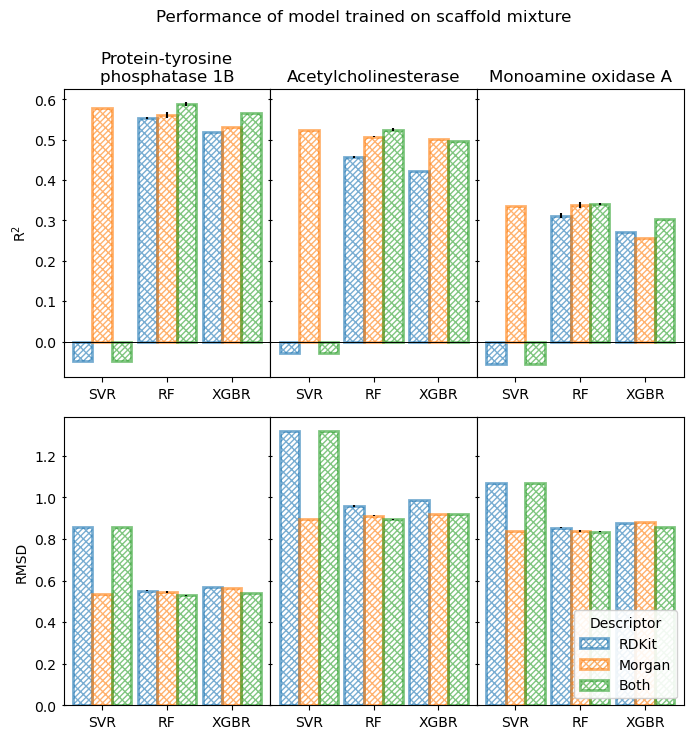

In [14]:
# Plot results:

fig, ax = plt.subplots(2, 3, figsize=(8, 8), sharey='row', 
                       gridspec_kw={'wspace' : 0, 
                                    'hspace' : 0.14})

bar_width = 0.3
models = ['SVR', 'RF', 'XGBR']
bar_colours = ['tab:blue', 'tab:orange', 'tab:green']

# Add axis line at y=0:
ax[0, 0].axhline(0, c='black', lw=0.7)
ax[0, 1].axhline(0, c='black', lw=0.7)
ax[0, 2].axhline(0, c='black', lw=0.7)

for s_i, stats in enumerate(['r2', 'rmsd']):
    for d_i, dataset in enumerate(['Tyro', 'Acetyl', 'Mono']):
        for i, desc in enumerate(['RDKit', 'Morgan', 'Both']):

            ax[s_i, d_i].bar(np.arange(len(df.loc[('Mix', dataset, desc)].loc[models]))+bar_width*(i-1), 
                           height=df.loc[('Mix', dataset, desc), (stats, 'mean')].loc[models], 
                           width=bar_width, 
                           label=desc, 
                           alpha=0.6, 
                           # fc='empty', 
                           ec=bar_colours[i], 
                           fc=bar_colours[i], 
                           lw=2, 
                           fill=False, 
                           hatch='//////\\\\\\',
                           yerr=df.loc[('Mix', dataset, desc), (stats, 'std')].loc[models])
            
        ax[s_i, d_i].set_xticks([0, 1, 2])
        ax[s_i, d_i].set_xticklabels(models)
        ax[s_i, d_i].tick_params(axis="y", direction="inout")

ax[0, 0].set_title('Protein-tyrosine\nphosphatase 1B')
ax[0, 1].set_title('Acetylcholinesterase')
ax[0, 2].set_title('Monoamine oxidase A')

ax[0, 0].set_ylabel('R$^{2}$')
ax[1, 0].set_ylabel('RMSD')

fig.suptitle('Performance of model trained on scaffold mixture')

# Modify legend:
plt.legend(loc='lower right', title='Descriptor', framealpha=0.9)

plt.savefig('Scaffold_Mix_results_bar_chart.png', dpi=400)
plt.show()